# POIs del Corredor — Av. Roosevelt · Overture Maps
**ITT Cali Inteligente · Equipo de Gobierno de Datos**

Descarga todos los puntos de interés (negocios, servicios, equipamiento) dentro del polígono de intervención de Av. Roosevelt usando Overture Maps — dataset open data de Meta, Microsoft, Amazon y TomTom.

**Sistema de referencia:** WGS84 (EPSG:4326) para toda la información geoespacial.

**Datos:** Se cargan automáticamente desde el repositorio Git del proyecto.

**Instrucciones:**
1. Ejecutar las celdas en orden
2. Los datos se cargan automáticamente desde Git
3. Los resultados y mapas se generan automáticamente

## Celda 1 — Instalación de dependencias

In [14]:
import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for p in ['overturemaps', 'geopandas', 'matplotlib', 'pandas', 'numpy', 'folium', 'shapely']:
    check_pkg(p)
print('Dependencias verificadas')

Dependencias verificadas


## Celda 2 — Importaciones y configuración

In [15]:
import os, json, warnings, datetime
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# Sistema de referencia
CRS_WGS84 = 'EPSG:4326'

plt.rcParams.update({
    'figure.facecolor': '#F4F6F9',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})
print(f'Sistema de referencia de trabajo: {CRS_WGS84}')
print('Configuración lista')

Sistema de referencia de trabajo: EPSG:4326
Configuración lista


## Celda 3 — Parámetros, rutas y detección de entorno

In [16]:
# Repositorio del proyecto (datos del corredor)
REPO_URL = 'https://github.com/j0rg3c45/indice-caminabilidad-roosevelt.git'
REPO_NAME = 'indice-caminabilidad-roosevelt'

# Repositorio de este proyecto (Índice de Concurrencia)
REPO_CONCURRENCIA_URL = 'https://github.com/j0rg3c45/Indice_Concurrencia.git'
REPO_CONCURRENCIA_NAME = 'Indice_Concurrencia'

# Detectar entorno: Colab o local
if os.path.exists('/content'):
    import subprocess as _sp
    os.chdir('/content')
    # Clonar repo de datos del corredor
    _sp.getoutput(f'rm -rf {REPO_NAME}')
    print(_sp.getoutput(f'git clone {REPO_URL}'))
    PROJECT_ROOT = Path(f'/content/{REPO_NAME}')
else:
    PROJECT_ROOT = Path(os.getcwd()).parent

# Rutas
DATA_DIR = PROJECT_ROOT / 'data' / 'itt_roosevelt' / 'Roosevelt' / 'Geojson_Roosevelt'
OUTPUT_DIR = Path(os.getcwd()).parent / 'outputs' if not os.path.exists('/content') else Path('/content') / REPO_CONCURRENCIA_NAME / 'outputs'
DATA_OUT_DIR = Path(os.getcwd()).parent / 'data' if not os.path.exists('/content') else Path('/content') / REPO_CONCURRENCIA_NAME / 'data'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Buscar polígono del buffer
import re
def find_file(base_dir, pattern):
    regex = re.compile(pattern, re.IGNORECASE)
    for root, _dirs, files in os.walk(base_dir):
        for f in files:
            if regex.search(f) and f.lower().endswith('.geojson'):
                return os.path.join(root, f)
    return None

POLIGONO_PATH = find_file(DATA_DIR, r'Geojson_tramos_Roosevelt_Buffer_100')

ZONA_NOMBRE = 'Av. Roosevelt — Cali'
POLIGONO_NOMBRE = 'Av. Roosevelt - Buffer 100m'

print(f'DATA_DIR: {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'Polígono: {"✅ " + Path(POLIGONO_PATH).name if POLIGONO_PATH else "❌ NO ENCONTRADO"}')

Cloning into 'indice-caminabilidad-roosevelt'...
DATA_DIR: /content/indice-caminabilidad-roosevelt/data/itt_roosevelt/Roosevelt/Geojson_Roosevelt
OUTPUT_DIR: /content/Indice_Concurrencia/outputs
Polígono: ✅ Geojson_tramos_Roosevelt_Buffer_100.geojson


## Celda 4 — Cargar polígono y definir bounding box

In [17]:
# Cargar polígono de intervención (buffer 100m)
gdf_poligono = gpd.read_file(POLIGONO_PATH)

# Asegurar WGS84
if gdf_poligono.crs is None:
    gdf_poligono = gdf_poligono.set_crs(CRS_WGS84)
elif gdf_poligono.crs.to_epsg() != 4326:
    gdf_poligono = gdf_poligono.to_crs(CRS_WGS84)

poligono = gdf_poligono.geometry.iloc[0]

# Bounding box para descarga de Overture Maps
bounds = gdf_poligono.total_bounds  # xmin, ymin, xmax, ymax
BBOX = (bounds[0], bounds[1], bounds[2], bounds[3])

print(f'\n=== ÁREA DE INTERVENCIÓN ===')
print(f'  Zona: {ZONA_NOMBRE}')
print(f'  CRS: {gdf_poligono.crs}')
print(f'  Bounding box: {BBOX}')
print(f'  Polígono cargado desde repositorio Git')


=== ÁREA DE INTERVENCIÓN ===
  Zona: Av. Roosevelt — Cali
  CRS: EPSG:4326
  Bounding box: (np.float64(-76.5423503813914), np.float64(3.425147106570745), np.float64(-76.53685514149288), np.float64(3.437614200293842))
  Polígono cargado desde repositorio Git


## Celda 5 — Descargar POIs desde Overture Maps

In [18]:
import subprocess

xmin, ymin, xmax, ymax = BBOX
RAW_FILE = 'roosevelt_overture_poi_raw.geojson'

cmd = [
    'overturemaps', 'download',
    f'--bbox={xmin},{ymin},{xmax},{ymax}',
    '-f', 'geojson',
    '--type=place',
    '-o', RAW_FILE
]

print('Descargando POIs de Overture Maps...')
print(f'Área: {POLIGONO_NOMBRE}')
print(f'Bounding box: {BBOX}')
print()

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    size = os.path.getsize(RAW_FILE) / 1024
    print(f'✅ Descarga exitosa — archivo: {size:.1f} KB')
else:
    print(f'❌ Error: {result.stderr}')

Descargando POIs de Overture Maps...
Área: Av. Roosevelt - Buffer 100m
Bounding box: (np.float64(-76.5423503813914), np.float64(3.425147106570745), np.float64(-76.53685514149288), np.float64(3.437614200293842))

✅ Descarga exitosa — archivo: 1065.6 KB


## Celda 6 — Filtrar POIs al polígono exacto

In [19]:
# Cargar POIs descargados
gdf = gpd.read_file(RAW_FILE)

# Asegurar CRS
if gdf.crs is None:
    gdf = gdf.set_crs(CRS_WGS84)

# Filtrar por polígono exacto
gdf_filtrado = gdf[gdf.geometry.within(poligono)].copy()

print(f'=== FILTRADO ESPACIAL ===')
print(f'  POIs en bounding box: {len(gdf)}')
print(f'  POIs dentro del polígono exacto: {len(gdf_filtrado)}')
print(f'  POIs descartados: {len(gdf) - len(gdf_filtrado)}')

=== FILTRADO ESPACIAL ===
  POIs en bounding box: 896
  POIs dentro del polígono exacto: 474
  POIs descartados: 422


## Celda 7 — Extraer atributos y clasificar en macrocategorías

In [20]:
# Funciones de extracción
def extraer_nombre(row):
    try:
        names = row.get('names', {})
        if isinstance(names, str):
            names = json.loads(names)
        primary = names.get('primary', '')
        if isinstance(primary, list):
            return primary[0] if primary else 'Sin nombre'
        return primary or 'Sin nombre'
    except:
        return 'Sin nombre'

def extraer_categoria(row):
    try:
        cats = row.get('categories', {})
        if isinstance(cats, str):
            cats = json.loads(cats)
        return cats.get('primary', 'sin_categoria')
    except:
        return 'sin_categoria'

def extraer_confianza(row):
    try:
        return round(float(row.get('confidence', 0)), 2)
    except:
        return None

# Agrupación en macrocategorías
def agrupar(cat):
    cat = str(cat).lower()
    if any(x in cat for x in ['restaurant','food','bakery','pizza','burger',
                                'chicken','coffee','bar','dessert','ice_cream',
                                'colombian','peruvian','vegetarian','fast_food','cafe','eat_and_drink']):
        return 'Gastronomía y bebidas'
    if any(x in cat for x in ['health','medical','dental','doctor','hospital',
                                'clinic','pharmacy','optician','nursing',
                                'counseling','mental_health','holistic','veterinarian']):
        return 'Salud y bienestar'
    if any(x in cat for x in ['store','shop','supermarket','market','clothing',
                                'electronics','furniture','sporting','jewelry',
                                'beauty_supply','thrift','wholesale','department',
                                'home_goods','candy','grocery','flowers']):
        return 'Comercio y tiendas'
    if any(x in cat for x in ['school','university','college','education',
                                'language','driving_school','dance','music',
                                'yoga','martial_arts','nursing_school','cosmetology','art_school']):
        return 'Educación y formación'
    if any(x in cat for x in ['hotel','lodging','hostel','accommodation']):
        return 'Alojamiento'
    if any(x in cat for x in ['professional','financial','insurance','accounting',
                                'marketing','advertising','consulting','technology',
                                'media','b2b','printing','business','legal','lawyer','software']):
        return 'Servicios profesionales'
    if any(x in cat for x in ['automotive','car','motorcycle','tire','bike',
                                'gas_station','transportation']):
        return 'Automotriz y transporte'
    if any(x in cat for x in ['beauty','spa','salon','barber','hair',
                                'esthetic','cosmetic']):
        return 'Belleza y estética'
    if any(x in cat for x in ['sport','gym','fitness','recreation','basketball',
                                'stadium','arena','active','park']):
        return 'Deporte y recreación'
    if any(x in cat for x in ['church','religious','cathedral','catholic']):
        return 'Religioso'
    if any(x in cat for x in ['community','social','nonprofit','organization',
                                'government','public','association','foundation']):
        return 'Comunitario e institucional'
    if any(x in cat for x in ['art','museum','landmark','historical','event',
                                'concert','entertainment','adult','travel']):
        return 'Cultura y entretenimiento'
    return 'Otros'

# Construir DataFrame limpio
df_lista = pd.DataFrame({
    'nombre': gdf_filtrado.apply(extraer_nombre, axis=1),
    'categoria': gdf_filtrado.apply(extraer_categoria, axis=1),
    'confianza': gdf_filtrado.apply(extraer_confianza, axis=1),
    'lat': gdf_filtrado.geometry.y,
    'lon': gdf_filtrado.geometry.x,
})
df_lista['macrocategoria'] = df_lista['categoria'].apply(agrupar)

print(f'=== POIs PROCESADOS ===')
print(f'Total: {len(df_lista)}')
print()
print('Distribución por macrocategoría:')
print(df_lista['macrocategoria'].value_counts().to_string())

=== POIs PROCESADOS ===
Total: 474

Distribución por macrocategoría:
macrocategoria
Otros                          87
Gastronomía y bebidas          68
Comercio y tiendas             56
Automotriz y transporte        51
Educación y formación          39
Salud y bienestar              36
Servicios profesionales        33
Cultura y entretenimiento      30
Belleza y estética             23
Religioso                      15
Alojamiento                    13
Comunitario e institucional    12
Deporte y recreación           11


## Celda 8 — Mapa interactivo con capas (Folium)

In [21]:
# Paleta de colores por macrocategoría
PALETTE = {
    'Gastronomía y bebidas':       '#E74C3C',
    'Salud y bienestar':           '#3498DB',
    'Comercio y tiendas':          '#F39C12',
    'Educación y formación':       '#9B59B6',
    'Alojamiento':                 '#1ABC9C',
    'Servicios profesionales':     '#2C3E50',
    'Automotriz y transporte':     '#7F8C8D',
    'Belleza y estética':          '#E91E8C',
    'Deporte y recreación':        '#27AE60',
    'Religioso':                   '#8E44AD',
    'Comunitario e institucional': '#16A085',
    'Cultura y entretenimiento':   '#D35400',
    'Otros':                       '#BDC3C7',
}

# Mapa interactivo — todo en WGS84
centroid = poligono.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=15,
               tiles='CartoDB positron', attr='CartoDB')

# Capas base adicionales
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Esri Satélite'
).add_to(m)
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
    attr='Google', name='Google Streets'
).add_to(m)
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google', name='Google Satélite'
).add_to(m)

# Polígono de intervención
folium.GeoJson(
    gdf_poligono.__geo_interface__,
    name='Polígono intervención (Buffer 100m)',
    style_function=lambda x: {'color': '#1B4F8A', 'fillColor': '#2E7D32',
                              'fillOpacity': 0.08, 'weight': 2}
).add_to(m)

# POIs por macrocategoría como capas separadas
for mac, grupo in df_lista.groupby('macrocategoria'):
    color = PALETTE.get(mac, '#BDC3C7')
    fg = folium.FeatureGroup(name=f'{mac} ({len(grupo)})', show=True)
    for _, row in grupo.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            color=color,
            fill=True,
            fill_opacity=0.7,
            weight=1,
            popup=folium.Popup(
                f"<b>{row['nombre']}</b><br>"
                f"Categoría: {row['categoria']}<br>"
                f"Macrocategoría: {mac}<br>"
                f"Confianza: {row['confianza']}",
                max_width=250
            )
        ).add_to(fg)
    fg.add_to(m)

# === Zonas espejo: polígonos + POIs ===
import zipfile as _zf_map

ESPEJO_DIR_MAP = PROJECT_ROOT / 'data' / 'Informacion_espejo' / 'geojson_espejo_poligonos'
zip_espejo_map = PROJECT_ROOT / 'data' / 'Informacion_espejo' / 'geojson_espejo_poligonos.zip'

if zip_espejo_map.exists() and not ESPEJO_DIR_MAP.exists():
    with _zf_map.ZipFile(zip_espejo_map, 'r') as z:
        z.extractall(zip_espejo_map.parent)
    print(f'  Descomprimido: {zip_espejo_map.name}')

ZONAS_ESPEJO_MAP = {
    'Calle 5': {'poligono': ESPEJO_DIR_MAP / 'calle_5_area_Espejo_Bf100.geojson', 'color': '#E53935'},
    'Calle 7': {'poligono': ESPEJO_DIR_MAP / 'calle_7_area_Espejo_Bf100.geojson', 'color': '#F5D76E'},
}

for zona_nombre, zona_cfg in ZONAS_ESPEJO_MAP.items():
    pol_path = zona_cfg['poligono']
    color_zona = zona_cfg['color']
    if not pol_path.exists():
        print(f'  ⚠ {zona_nombre}: polígono no encontrado')
        continue
    
    # Cargar polígono espejo
    gdf_esp_map = gpd.read_file(pol_path)
    if gdf_esp_map.crs is None:
        gdf_esp_map = gdf_esp_map.set_crs(CRS_WGS84)
    elif gdf_esp_map.crs.to_epsg() != 4326:
        gdf_esp_map = gdf_esp_map.to_crs(CRS_WGS84)
    
    # Agregar polígono al mapa
    folium.GeoJson(
        gdf_esp_map.__geo_interface__,
        name=f'Polígono {zona_nombre} (Espejo)',
        style_function=lambda x, c=color_zona: {
            'color': c, 'weight': 2, 'dashArray': '5,5',
            'fillColor': c, 'fillOpacity': 0.05
        }
    ).add_to(m)
    
    # Descargar POIs para esta zona espejo
    poligono_esp_map = gdf_esp_map.geometry.iloc[0]
    bounds_esp_map = gdf_esp_map.total_bounds
    bbox_esp_map = (bounds_esp_map[0], bounds_esp_map[1], bounds_esp_map[2], bounds_esp_map[3])
    
    raw_esp_map = f'poi_raw_map_{zona_nombre.lower().replace(" ", "_")}.geojson'
    cmd_esp_map = [
        'overturemaps', 'download',
        f'--bbox={bbox_esp_map[0]},{bbox_esp_map[1]},{bbox_esp_map[2]},{bbox_esp_map[3]}',
        '-f', 'geojson', '--type=place', '-o', raw_esp_map
    ]
    
    print(f'  Descargando POIs para {zona_nombre}...')
    result_esp_map = subprocess.run(cmd_esp_map, capture_output=True, text=True)
    
    if result_esp_map.returncode != 0:
        print(f'   Error descarga {zona_nombre}')
        continue
    
    # Filtrar y clasificar
    gdf_esp_raw_map = gpd.read_file(raw_esp_map)
    if gdf_esp_raw_map.crs is None:
        gdf_esp_raw_map = gdf_esp_raw_map.set_crs(CRS_WGS84)
    gdf_esp_filt_map = gdf_esp_raw_map[gdf_esp_raw_map.geometry.within(poligono_esp_map)].copy()
    
    df_esp_map = pd.DataFrame({
        'nombre': gdf_esp_filt_map.apply(extraer_nombre, axis=1),
        'categoria': gdf_esp_filt_map.apply(extraer_categoria, axis=1),
        'confianza': gdf_esp_filt_map.apply(extraer_confianza, axis=1),
        'lat': gdf_esp_filt_map.geometry.y,
        'lon': gdf_esp_filt_map.geometry.x,
    })
    df_esp_map['macrocategoria'] = df_esp_map['categoria'].apply(agrupar)
    
    print(f'   {zona_nombre}: {len(df_esp_map)} POIs')
    
    # Agregar POIs por macrocategoría como capas
    for mac, grupo in df_esp_map.groupby('macrocategoria'):
        color_poi = PALETTE.get(mac, '#BDC3C7')
        fg_esp = folium.FeatureGroup(name=f'{zona_nombre} · {mac} ({len(grupo)})', show=False)
        for _, row in grupo.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=4,
                color=color_zona,
                fill=True,
                fill_color=color_poi,
                fill_opacity=0.6,
                weight=1,
                popup=folium.Popup(
                    f"<b>[{zona_nombre}]</b><br>"
                    f"<b>{row['nombre']}</b><br>"
                    f"Categoría: {row['categoria']}<br>"
                    f"Macrocategoría: {mac}<br>"
                    f"Confianza: {row['confianza']}",
                    max_width=250
                )
            ).add_to(fg_esp)
        fg_esp.add_to(m)

folium.LayerControl().add_to(m)
print(f'Mapa interactivo generado — {len(df_lista)} POIs en {len(PALETTE)} macrocategorías')
print(f'CRS: {CRS_WGS84}')
m

  Descomprimido: geojson_espejo_poligonos.zip
  Descargando POIs para Calle 5...
   Calle 5: 246 POIs
  Descargando POIs para Calle 7...
   Calle 7: 302 POIs
Mapa interactivo generado — 474 POIs en 13 macrocategorías
CRS: EPSG:4326


## Celda 9 — Mapa estático con categorías agrupadas

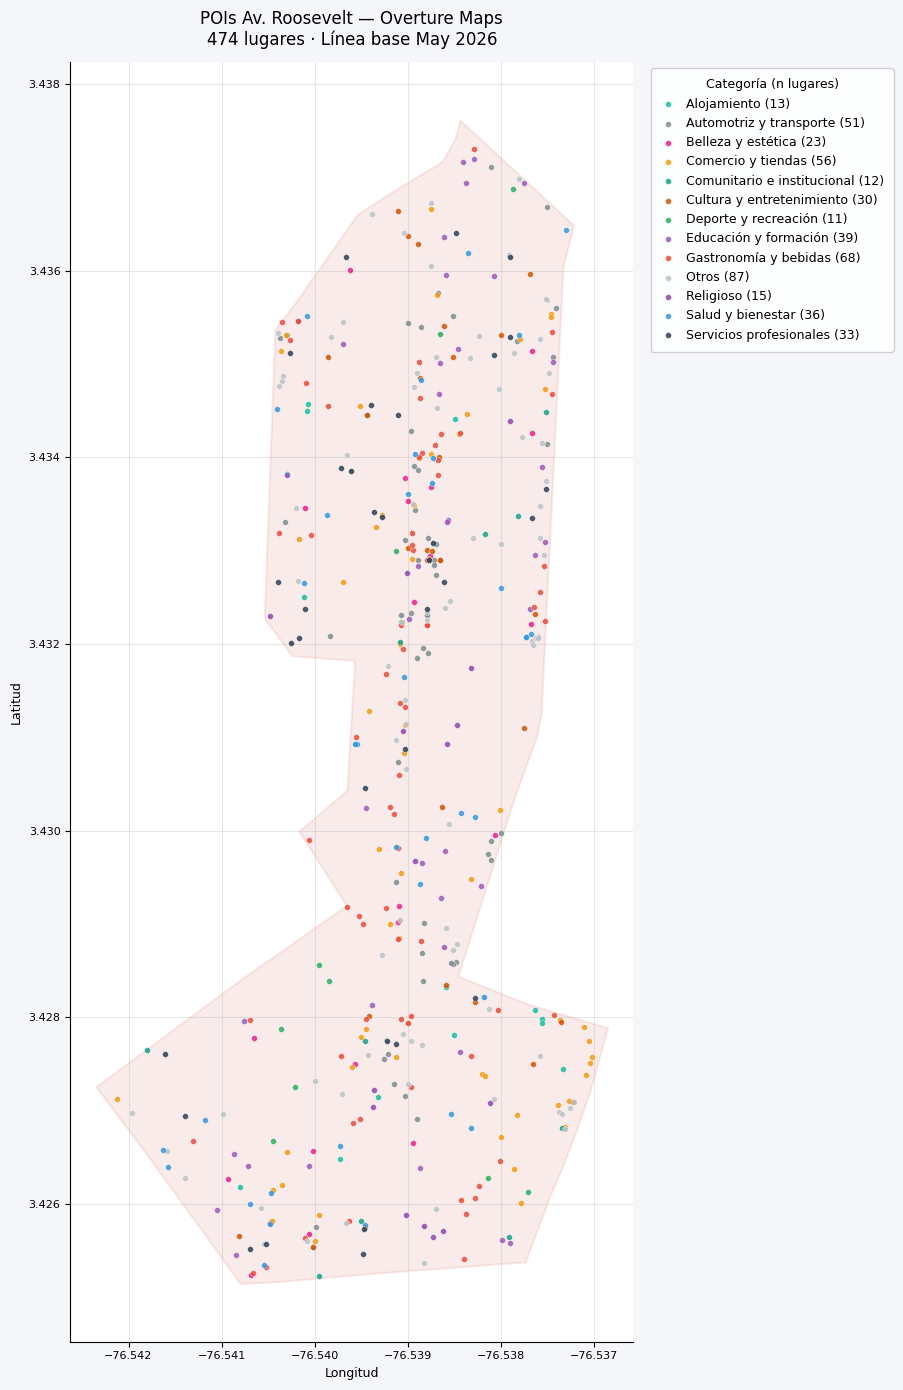

Mapa guardado: /content/Indice_Concurrencia/outputs/roosevelt_overture_poi_mapa.png


In [22]:
fig, ax = plt.subplots(figsize=(8, 14))

# Polígono
gdf_poligono.plot(
    ax=ax, color='#CB4335', alpha=0.10,
    edgecolor='#CB4335', linewidth=1.5
)

# POIs por macrocategoría
for mac, grupo in df_lista.groupby('macrocategoria'):
    ax.scatter(
        grupo['lon'], grupo['lat'],
        color=PALETTE.get(mac, '#BDC3C7'),
        s=18, zorder=5, alpha=0.85,
        edgecolors='white', linewidth=0.3,
        label=f"{mac} ({len(grupo)})"
    )

ax.set_title(
    f'POIs Av. Roosevelt — Overture Maps\n'
    f'{len(df_lista)} lugares · Línea base {datetime.date.today().strftime("%B %Y")}',
    fontsize=12, pad=12
)
ax.set_xlabel('Longitud', fontsize=9)
ax.set_ylabel('Latitud', fontsize=9)
ax.tick_params(labelsize=8)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
    framealpha=0.9,
    borderpad=0.8,
    handlelength=1.2,
    title='Categoría (n lugares)',
    title_fontsize=9
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roosevelt_overture_poi_mapa.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mapa guardado: {OUTPUT_DIR / "roosevelt_overture_poi_mapa.png"}')

## Celda 9B — Gráficos de distribución de POIs

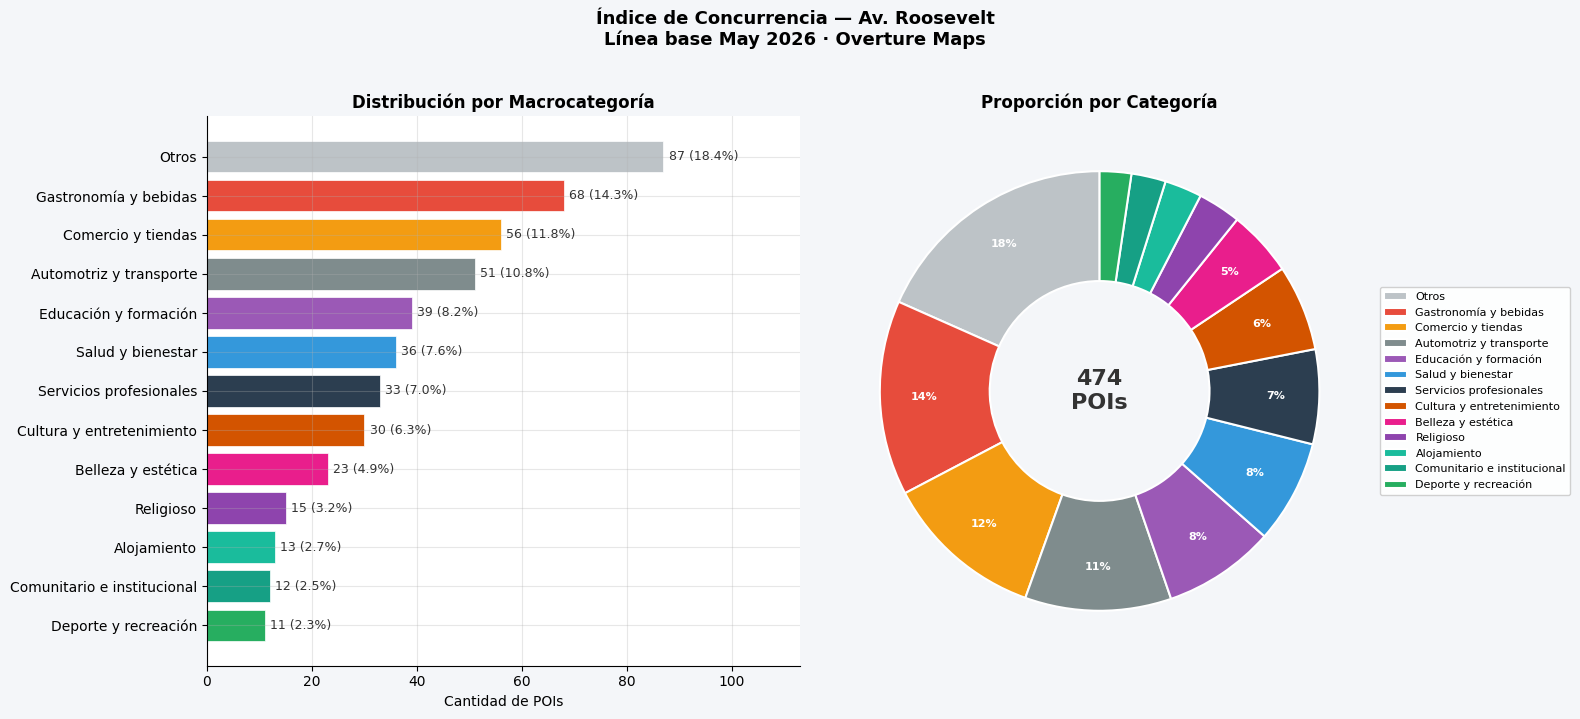

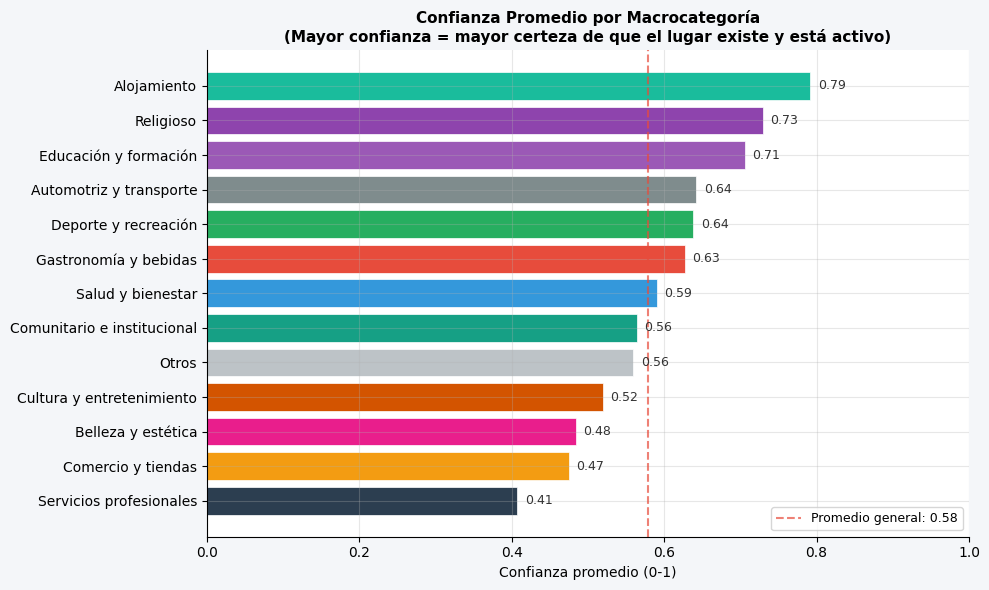


Gráficos guardados en: /content/Indice_Concurrencia/outputs


In [23]:
# === GRÁFICO 1: Barras horizontales por macrocategoría ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Datos ordenados
conteo = df_lista['macrocategoria'].value_counts()
colores_barras = [PALETTE.get(cat, '#BDC3C7') for cat in conteo.index]

# Subplot 1: Barras horizontales con cantidad
bars = axes[0].barh(conteo.index, conteo.values, color=colores_barras, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Cantidad de POIs', fontsize=10)
axes[0].set_title('Distribución por Macrocategoría', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
# Agregar etiquetas de valor
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val} ({val/len(df_lista)*100:.1f}%)',
                va='center', fontsize=9, color='#333')
axes[0].set_xlim(0, conteo.max() * 1.3)

# Subplot 2: Donut chart (proporción)
wedges, texts, autotexts = axes[1].pie(
    conteo.values,
    labels=None,
    colors=colores_barras,
    autopct=lambda pct: f'{pct:.0f}%' if pct > 4 else '',
    pctdistance=0.8,
    startangle=90,
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 1.5}
)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Centro del donut con total
axes[1].text(0, 0, f'{len(df_lista)}\nPOIs', ha='center', va='center',
             fontsize=16, fontweight='bold', color='#333')
axes[1].set_title('Proporción por Categoría', fontsize=12, fontweight='bold')

# Leyenda compacta
axes[1].legend(conteo.index, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=8, framealpha=0.9)

plt.suptitle(f'Índice de Concurrencia — Av. Roosevelt\n'
             f'Línea base {datetime.date.today().strftime("%B %Y")} · Overture Maps',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'graf_distribucion_macrocategorias.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRÁFICO 2: Confianza promedio por macrocategoría ===
fig, ax = plt.subplots(figsize=(10, 6))

conf_por_cat = df_lista.groupby('macrocategoria')['confianza'].agg(['mean', 'count']).sort_values('mean', ascending=True)
colores_conf = [PALETTE.get(cat, '#BDC3C7') for cat in conf_por_cat.index]

bars = ax.barh(conf_por_cat.index, conf_por_cat['mean'], color=colores_conf,
               edgecolor='white', linewidth=0.5)

# Línea de referencia (promedio general)
media_global = df_lista['confianza'].mean()
ax.axvline(media_global, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Promedio general: {media_global:.2f}')

# Etiquetas
for bar, val in zip(bars, conf_por_cat['mean']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color='#333')

ax.set_xlabel('Confianza promedio (0-1)', fontsize=10)
ax.set_title('Confianza Promedio por Macrocategoría\n'
             '(Mayor confianza = mayor certeza de que el lugar existe y está activo)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'graf_confianza_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nGráficos guardados en: {OUTPUT_DIR}')

## Celda 10 — Exportar CSV limpio para el datalake

In [24]:
df_export = df_lista.copy()
df_export['fecha_extraccion'] = datetime.date.today().isoformat()
df_export['poligono'] = POLIGONO_NOMBRE
df_export['fuente'] = 'Overture Maps Foundation'
df_export['momento'] = 'linea_base_pre_intervencion'
df_export['release_overture'] = '2026-04-15'

# Exportar
csv_path = DATA_OUT_DIR / 'roosevelt_overture_poi.csv'
geojson_path = DATA_OUT_DIR / 'roosevelt_overture_poi.geojson'

df_export.to_csv(csv_path, index=False)
gdf_filtrado.to_file(geojson_path, driver='GeoJSON')

print(f'=== EXPORTACIÓN ===')
print(f'  CSV: {csv_path.name} ({len(df_export)} registros)')
print(f'  GeoJSON: {geojson_path.name}')
print()
print('Columnas del CSV:')
for col in df_export.columns:
    print(f'  - {col}')
print()
print('Para comparar después de las obras: cambiar momento a post_intervencion')
print('y repetir con el release más reciente de Overture Maps.')

=== EXPORTACIÓN ===
  CSV: roosevelt_overture_poi.csv (474 registros)
  GeoJSON: roosevelt_overture_poi.geojson

Columnas del CSV:
  - nombre
  - categoria
  - confianza
  - lat
  - lon
  - macrocategoria
  - fecha_extraccion
  - poligono
  - fuente
  - momento
  - release_overture

Para comparar después de las obras: cambiar momento a post_intervencion
y repetir con el release más reciente de Overture Maps.


## Celda 11 — POIs en Territorios Espejo (Calle 5 y Calle 7)

In [25]:
# === Descargar POIs para zonas espejo usando polígonos del repo de caminabilidad ===
import zipfile

# Ruta a polígonos espejo
ESPEJO_DIR = PROJECT_ROOT / 'data' / 'Informacion_espejo' / 'geojson_espejo_poligonos'
zip_espejo = PROJECT_ROOT / 'data' / 'Informacion_espejo' / 'geojson_espejo_poligonos.zip'

# Descomprimir si es necesario
if zip_espejo.exists() and not ESPEJO_DIR.exists():
    with zipfile.ZipFile(zip_espejo, 'r') as z:
        z.extractall(zip_espejo.parent)
    print(f'Descomprimido: {zip_espejo.name}')

ZONAS_ESPEJO = {
    'Calle 5': ESPEJO_DIR / 'calle_5_area_Espejo_Bf100.geojson',
    'Calle 7': ESPEJO_DIR / 'calle_7_area_Espejo_Bf100.geojson',
}

resultados_espejo = {}

for zona_nombre, poligono_path in ZONAS_ESPEJO.items():
    if not poligono_path.exists():
        print(f'⚠ {zona_nombre}: polígono no encontrado')
        continue
    
    print(f'\n{"═" * 50}')
    print(f'  {zona_nombre}')
    print(f'{"═" * 50}')
    
    # Cargar polígono espejo
    gdf_esp = gpd.read_file(poligono_path)
    if gdf_esp.crs is None:
        gdf_esp = gdf_esp.set_crs(CRS_WGS84)
    elif gdf_esp.crs.to_epsg() != 4326:
        gdf_esp = gdf_esp.to_crs(CRS_WGS84)
    
    poligono_esp = gdf_esp.geometry.iloc[0]
    bounds_esp = gdf_esp.total_bounds
    bbox_esp = (bounds_esp[0], bounds_esp[1], bounds_esp[2], bounds_esp[3])
    
    # Descargar POIs para esta zona
    raw_file_esp = f'poi_raw_{zona_nombre.lower().replace(" ", "_")}.geojson'
    cmd_esp = [
        'overturemaps', 'download',
        f'--bbox={bbox_esp[0]},{bbox_esp[1]},{bbox_esp[2]},{bbox_esp[3]}',
        '-f', 'geojson',
        '--type=place',
        '-o', raw_file_esp
    ]
    
    print(f'  Descargando POIs...')
    result_esp = subprocess.run(cmd_esp, capture_output=True, text=True)
    
    if result_esp.returncode != 0:
        print(f'  ❌ Error en descarga: {result_esp.stderr}')
        continue
    
    # Cargar y filtrar
    gdf_esp_raw = gpd.read_file(raw_file_esp)
    if gdf_esp_raw.crs is None:
        gdf_esp_raw = gdf_esp_raw.set_crs(CRS_WGS84)
    
    gdf_esp_filtrado = gdf_esp_raw[gdf_esp_raw.geometry.within(poligono_esp)].copy()
    
    # Extraer atributos y clasificar
    df_esp = pd.DataFrame({
        'nombre': gdf_esp_filtrado.apply(extraer_nombre, axis=1),
        'categoria': gdf_esp_filtrado.apply(extraer_categoria, axis=1),
        'confianza': gdf_esp_filtrado.apply(extraer_confianza, axis=1),
        'lat': gdf_esp_filtrado.geometry.y,
        'lon': gdf_esp_filtrado.geometry.x,
    })
    df_esp['macrocategoria'] = df_esp['categoria'].apply(agrupar)
    
    resultados_espejo[zona_nombre] = df_esp
    
    print(f'  POIs en bbox: {len(gdf_esp_raw)}')
    print(f'  POIs en polígono: {len(df_esp)}')
    print(f'  Confianza promedio: {df_esp["confianza"].mean():.2f}')
    print(f'  Distribución:')
    print(df_esp['macrocategoria'].value_counts().head(5).to_string())

print(f'\n✅ Zonas espejo procesadas: {len(resultados_espejo)}')


══════════════════════════════════════════════════
  Calle 5
══════════════════════════════════════════════════
  Descargando POIs...


  POIs en bbox: 546
  POIs en polígono: 246
  Confianza promedio: 0.60
  Distribución:
macrocategoria
Otros                        55
Gastronomía y bebidas        50
Educación y formación        24
Comercio y tiendas           23
Cultura y entretenimiento    19

══════════════════════════════════════════════════
  Calle 7
══════════════════════════════════════════════════
  Descargando POIs...
  POIs en bbox: 637
  POIs en polígono: 302
  Confianza promedio: 0.57
  Distribución:
macrocategoria
Otros                      62
Automotriz y transporte    43
Comercio y tiendas         39
Gastronomía y bebidas      36
Educación y formación      29

✅ Zonas espejo procesadas: 2


## Celda 12 — Comparación Roosevelt vs Territorios Espejo

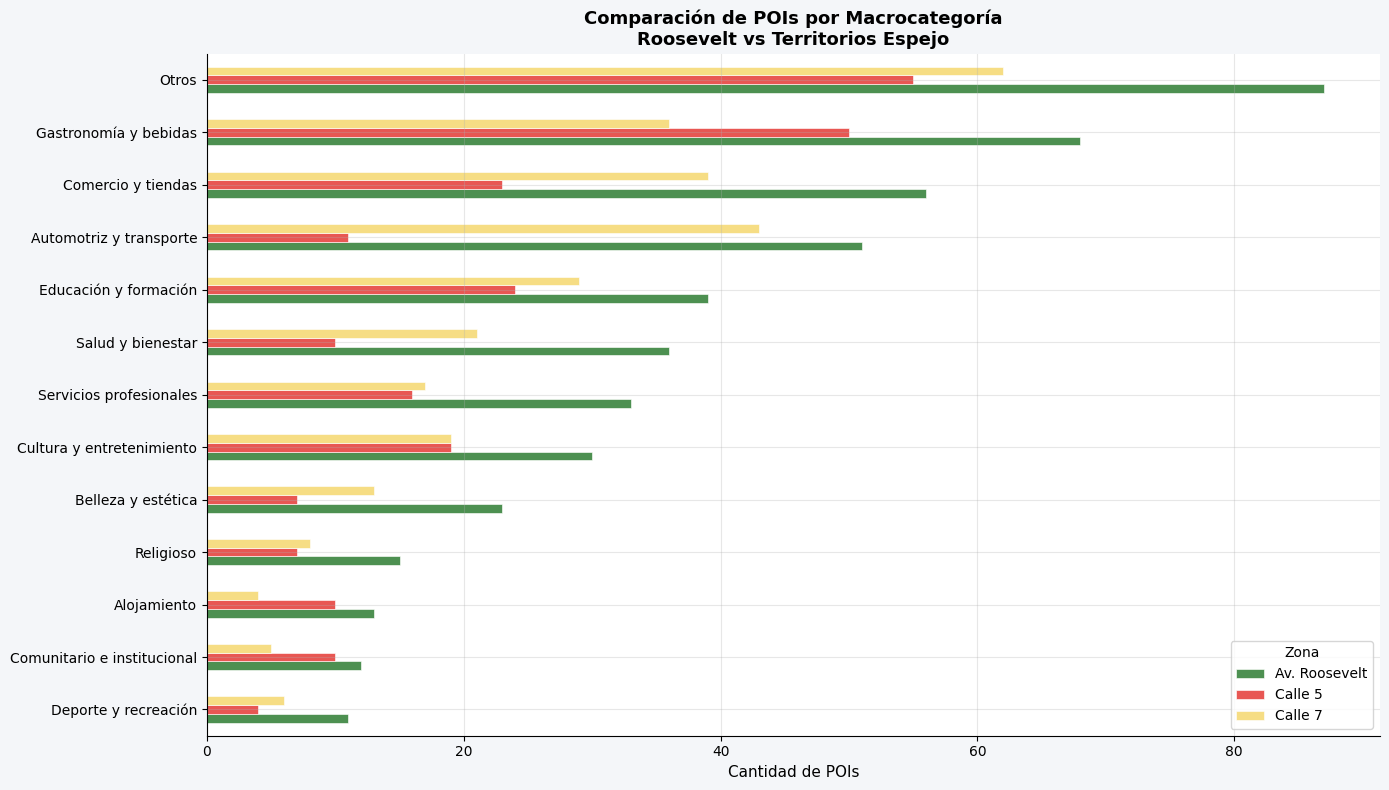

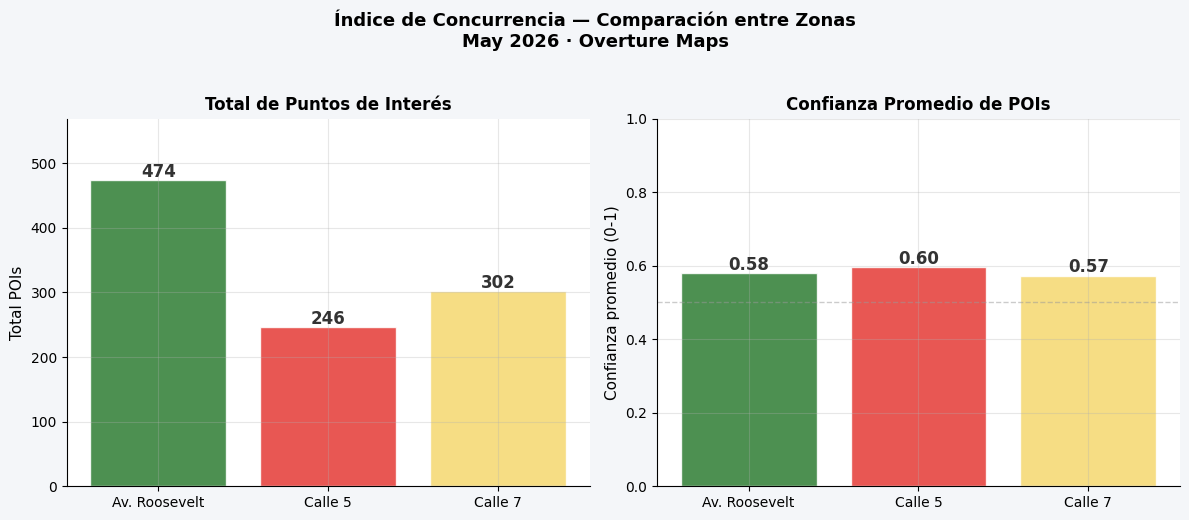


════════════════════════════════════════════════════════════
TABLA COMPARATIVA — Índice de Concurrencia
════════════════════════════════════════════════════════════
Zona                 Total POIs   Confianza    Categorías  
------------------------------------------------------------
Av. Roosevelt        474          0.58         13          
Calle 5              246          0.60         13          
Calle 7              302          0.57         13          
════════════════════════════════════════════════════════════


In [26]:
# === Construir tabla comparativa ===
filas = []

# Roosevelt
for mac in PALETTE.keys():
    n = len(df_lista[df_lista['macrocategoria'] == mac])
    filas.append({'zona': 'Av. Roosevelt', 'macrocategoria': mac, 'cantidad': n})

# Zonas espejo
for zona_nombre, df_esp in resultados_espejo.items():
    for mac in PALETTE.keys():
        n = len(df_esp[df_esp['macrocategoria'] == mac])
        filas.append({'zona': zona_nombre, 'macrocategoria': mac, 'cantidad': n})

df_comparacion = pd.DataFrame(filas)

# === GRÁFICO 1: Barras agrupadas por macrocategoría ===
fig, ax = plt.subplots(figsize=(14, 8))

pivot = df_comparacion.pivot_table(index='macrocategoria', columns='zona', values='cantidad', fill_value=0)
# Ordenar por Roosevelt
if 'Av. Roosevelt' in pivot.columns:
    pivot = pivot.sort_values('Av. Roosevelt', ascending=True)

colores_zonas = ['#2E7D32', '#E53935', '#F5D76E']
pivot.plot(kind='barh', ax=ax, color=colores_zonas[:len(pivot.columns)], alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Cantidad de POIs', fontsize=11)
ax.set_ylabel('')
ax.set_title('Comparación de POIs por Macrocategoría\nRoosevelt vs Territorios Espejo',
             fontsize=13, fontweight='bold')
ax.legend(title='Zona', fontsize=10, title_fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'graf_comparacion_pois_espejo.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRÁFICO 2: Resumen total y confianza ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total POIs por zona
zonas = ['Av. Roosevelt'] + list(resultados_espejo.keys())
totales = [len(df_lista)] + [len(df) for df in resultados_espejo.values()]
confianzas = [df_lista['confianza'].mean()] + [df['confianza'].mean() for df in resultados_espejo.values()]

bars1 = axes[0].bar(zonas, totales, color=colores_zonas[:len(zonas)], alpha=0.85, edgecolor='white', linewidth=1)
for bar, val in zip(bars1, totales):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}', ha='center', fontsize=12, fontweight='bold', color='#333')
axes[0].set_ylabel('Total POIs', fontsize=11)
axes[0].set_title('Total de Puntos de Interés', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(totales) * 1.2)

# Confianza promedio por zona
bars2 = axes[1].bar(zonas, confianzas, color=colores_zonas[:len(zonas)], alpha=0.85, edgecolor='white', linewidth=1)
for bar, val in zip(bars2, confianzas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=12, fontweight='bold', color='#333')
axes[1].set_ylabel('Confianza promedio (0-1)', fontsize=11)
axes[1].set_title('Confianza Promedio de POIs', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].axhline(0.5, color='#999', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle(f'Índice de Concurrencia — Comparación entre Zonas\n'
             f'{datetime.date.today().strftime("%B %Y")} · Overture Maps',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'graf_resumen_comparacion_zonas.png', dpi=150, bbox_inches='tight')
plt.show()

# === Tabla resumen ===
print('\n' + '═' * 60)
print('TABLA COMPARATIVA — Índice de Concurrencia')
print('═' * 60)
print(f'{"Zona":<20} {"Total POIs":<12} {"Confianza":<12} {"Categorías":<12}')
print('-' * 60)
print(f'{"Av. Roosevelt":<20} {len(df_lista):<12} {df_lista["confianza"].mean():<12.2f} {df_lista["macrocategoria"].nunique():<12}')
for zona_nombre, df_esp in resultados_espejo.items():
    print(f'{zona_nombre:<20} {len(df_esp):<12} {df_esp["confianza"].mean():<12.2f} {df_esp["macrocategoria"].nunique():<12}')
print('═' * 60)

## Celda 13 — Cálculo del Índice de Concurrencia

  ÍNDICE DE CONCURRENCIA — RESULTADOS
  Fórmula: IC = 0.40×Densidad + 0.40×Diversidad + 0.20×Confianza
  Escala: 0-100 (mayor = más vitalidad económica)

Zona             POIs   Dens.   Div.    Conf.   │ D_n    Dv_n   C_n    │ IC    
──────────────────────────────────────────────────────────────────────
Av. Roosevelt    474    11.05   92.73   0.579   │ 39.3   96.5   55.8   │ 65.5  
Calle 5          246    9.09    88.97   0.595   │ 30.8   90.7   59.0   │ 60.4  
Calle 7          302    8.1     89.73   0.572   │ 26.5   91.9   54.4   │ 58.2  
──────────────────────────────────────────────────────────────────────

Leyenda:
  Dens. = POIs/ha | Div. = Shannon norm (0-100) | Conf. = promedio (0-1)
  D_n, Dv_n, C_n = componentes normalizados (0-100)
  IC = Índice de Concurrencia final (0-100)

  Av. Roosevelt:  IC = 65.5  →  Alto
  Calle 5:       IC = 60.4  →  Alto
  Calle 7:       IC = 58.2  →  Alto


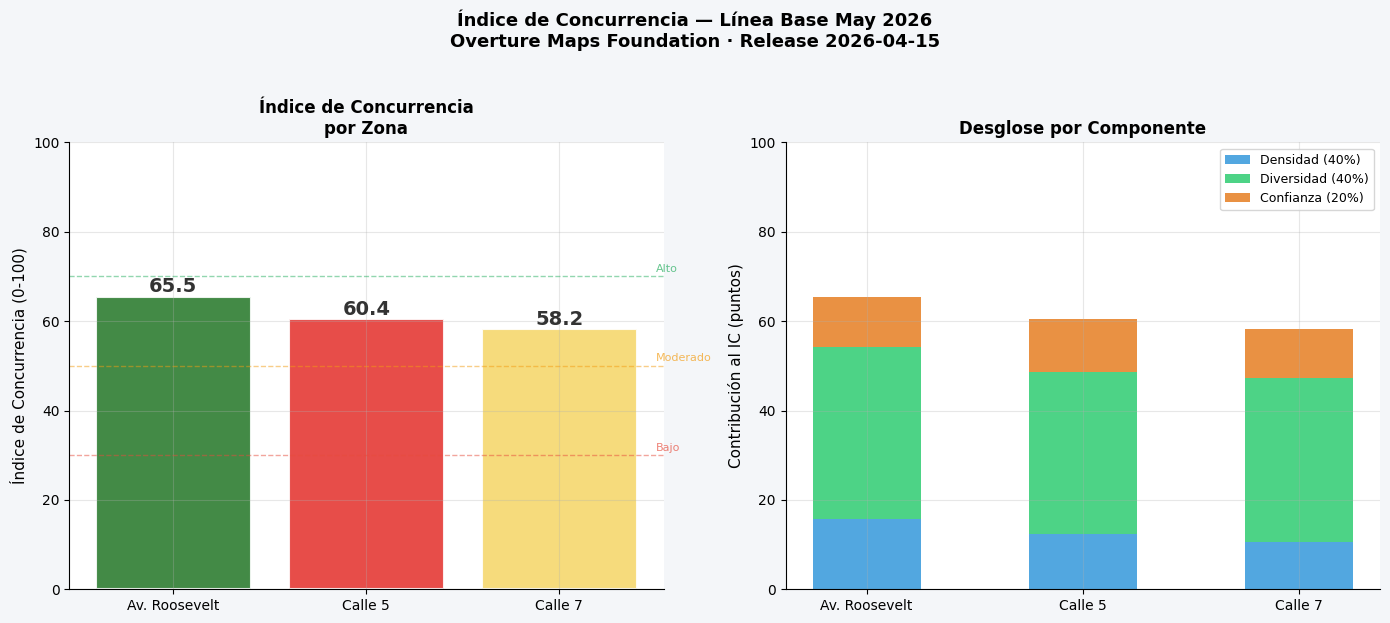


Gráfico guardado: /content/Indice_Concurrencia/outputs/graf_indice_concurrencia.png


In [27]:
# === ÍNDICE DE CONCURRENCIA ===
# Fórmula: IC = 0.40 × Densidad_norm + 0.40 × Diversidad_norm + 0.20 × Confianza_norm

# Parámetros de normalización (refs fijos)
REFS = {
    'densidad':   {'ref_min': 2,    'ref_max': 25,   'peso': 0.40},
    'diversidad': {'ref_min': 30,   'ref_max': 95,   'peso': 0.40},
    'confianza':  {'ref_min': 0.30, 'ref_max': 0.80, 'peso': 0.20},
}

N_MACROCATEGORIAS = 13  # Total de macrocategorías definidas

def normalizar(valor, ref_min, ref_max):
    """Normaliza un valor a escala 0-100 con refs fijos."""
    if ref_max == ref_min:
        return 100.0
    return np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)

def shannon_normalizado(df, col='macrocategoria', n_categorias=N_MACROCATEGORIAS):
    """Calcula el índice de Shannon normalizado (0-100)."""
    conteos = df[col].value_counts()
    proporciones = conteos / conteos.sum()
    H = -np.sum(proporciones * np.log(proporciones))
    H_max = np.log(n_categorias)
    return (H / H_max) * 100 if H_max > 0 else 0

def calcular_indice(df, area_ha):
    """Calcula el Índice de Concurrencia para un DataFrame de POIs."""
    # Componentes crudos
    densidad = len(df) / area_ha
    diversidad = shannon_normalizado(df)
    confianza = df['confianza'].mean()
    
    # Normalizar cada componente
    densidad_norm = normalizar(densidad, REFS['densidad']['ref_min'], REFS['densidad']['ref_max'])
    diversidad_norm = normalizar(diversidad, REFS['diversidad']['ref_min'], REFS['diversidad']['ref_max'])
    confianza_norm = normalizar(confianza, REFS['confianza']['ref_min'], REFS['confianza']['ref_max'])
    
    # Índice compuesto
    IC = (REFS['densidad']['peso'] * densidad_norm +
          REFS['diversidad']['peso'] * diversidad_norm +
          REFS['confianza']['peso'] * confianza_norm)
    
    return {
        'total_pois': len(df),
        'area_ha': area_ha,
        'densidad_cruda': round(densidad, 2),
        'diversidad_cruda': round(diversidad, 2),
        'confianza_cruda': round(confianza, 3),
        'densidad_norm': round(densidad_norm, 1),
        'diversidad_norm': round(diversidad_norm, 1),
        'confianza_norm': round(confianza_norm, 1),
        'IC': round(IC, 1),
    }

# === Calcular para Roosevelt ===
AREA_ROOSEVELT_HA = 42.9
ic_roosevelt = calcular_indice(df_lista, AREA_ROOSEVELT_HA)

# === Calcular para zonas espejo ===
# Áreas de las zonas espejo (del notebook de caminabilidad)
AREAS_ESPEJO = {'Calle 5': 27.05, 'Calle 7': 37.28}

ic_espejo = {}
for zona_nombre, df_esp in resultados_espejo.items():
    area_esp = AREAS_ESPEJO.get(zona_nombre, 30.0)
    ic_espejo[zona_nombre] = calcular_indice(df_esp, area_esp)

# === Mostrar resultados ===
print('=' * 70)
print('  ÍNDICE DE CONCURRENCIA — RESULTADOS')
print('=' * 70)
print(f'  Fórmula: IC = 0.40×Densidad + 0.40×Diversidad + 0.20×Confianza')
print(f'  Escala: 0-100 (mayor = más vitalidad económica)')
print()

# Tabla de componentes
print(f'{"Zona":<16} {"POIs":<6} {"Dens.":<7} {"Div.":<7} {"Conf.":<7} │ {"D_n":<6} {"Dv_n":<6} {"C_n":<6} │ {"IC":<6}')
print('─' * 70)

r = ic_roosevelt
print(f'{"Av. Roosevelt":<16} {r["total_pois"]:<6} {r["densidad_cruda"]:<7} {r["diversidad_cruda"]:<7} {r["confianza_cruda"]:<7} │ {r["densidad_norm"]:<6} {r["diversidad_norm"]:<6} {r["confianza_norm"]:<6} │ {r["IC"]:<6}')

for zona_nombre, ic in ic_espejo.items():
    print(f'{zona_nombre:<16} {ic["total_pois"]:<6} {ic["densidad_cruda"]:<7} {ic["diversidad_cruda"]:<7} {ic["confianza_cruda"]:<7} │ {ic["densidad_norm"]:<6} {ic["diversidad_norm"]:<6} {ic["confianza_norm"]:<6} │ {ic["IC"]:<6}')

print('─' * 70)
print()
print('Leyenda:')
print('  Dens. = POIs/ha | Div. = Shannon norm (0-100) | Conf. = promedio (0-1)')
print('  D_n, Dv_n, C_n = componentes normalizados (0-100)')
print('  IC = Índice de Concurrencia final (0-100)')
print()

# Clasificación
def clasificar_ic(ic):
    if ic < 30: return 'Bajo'
    elif ic < 50: return 'Moderado'
    elif ic < 70: return 'Alto'
    else: return 'Muy alto'

print(f'  Av. Roosevelt:  IC = {r["IC"]}  →  {clasificar_ic(r["IC"])}')
for zona_nombre, ic in ic_espejo.items():
    print(f'  {zona_nombre}:       IC = {ic["IC"]}  →  {clasificar_ic(ic["IC"])}')

# === GRÁFICO: Índice de Concurrencia comparativo ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: IC final por zona
zonas_ic = ['Av. Roosevelt'] + list(ic_espejo.keys())
valores_ic = [ic_roosevelt['IC']] + [ic['IC'] for ic in ic_espejo.values()]
colores_ic = ['#2E7D32', '#E53935', '#F5D76E']

bars = axes[0].bar(zonas_ic, valores_ic, color=colores_ic[:len(zonas_ic)],
                   edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, val in zip(bars, valores_ic):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}', ha='center', fontsize=14, fontweight='bold', color='#333')

# Líneas de clasificación
axes[0].axhline(30, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axhline(50, color='#F39C12', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axhline(70, color='#27AE60', linestyle='--', linewidth=1, alpha=0.5)
axes[0].text(len(zonas_ic)-0.5, 31, 'Bajo', fontsize=8, color='#E74C3C', alpha=0.7)
axes[0].text(len(zonas_ic)-0.5, 51, 'Moderado', fontsize=8, color='#F39C12', alpha=0.7)
axes[0].text(len(zonas_ic)-0.5, 71, 'Alto', fontsize=8, color='#27AE60', alpha=0.7)

axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Índice de Concurrencia (0-100)', fontsize=11)
axes[0].set_title('Índice de Concurrencia\npor Zona', fontsize=12, fontweight='bold')

# Gráfico 2: Componentes desglosados (stacked)
x = np.arange(len(zonas_ic))
width = 0.5

d_vals = [ic_roosevelt['densidad_norm'] * 0.40] + [ic['densidad_norm'] * 0.40 for ic in ic_espejo.values()]
dv_vals = [ic_roosevelt['diversidad_norm'] * 0.40] + [ic['diversidad_norm'] * 0.40 for ic in ic_espejo.values()]
c_vals = [ic_roosevelt['confianza_norm'] * 0.20] + [ic['confianza_norm'] * 0.20 for ic in ic_espejo.values()]

axes[1].bar(x, d_vals, width, label='Densidad (40%)', color='#3498DB', alpha=0.85)
axes[1].bar(x, dv_vals, width, bottom=d_vals, label='Diversidad (40%)', color='#2ECC71', alpha=0.85)
axes[1].bar(x, c_vals, width, bottom=[d+dv for d, dv in zip(d_vals, dv_vals)],
            label='Confianza (20%)', color='#E67E22', alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(zonas_ic)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Contribución al IC (puntos)', fontsize=11)
axes[1].set_title('Desglose por Componente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')

plt.suptitle(f'Índice de Concurrencia — Línea Base {datetime.date.today().strftime("%B %Y")}\n'
             f'Overture Maps Foundation · Release 2026-04-15',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'graf_indice_concurrencia.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nGráfico guardado: {OUTPUT_DIR / "graf_indice_concurrencia.png"}')

## Celda 13B — Índice de Concurrencia Mejorado (ponderación espacial)

In [ ]:
# === IC v2 — PONDERACION ESPACIAL POR AREA ===
# Poblacion proporcional al area de interseccion barrio/zona.
# Pob_zona = SUM(pob_barrio * area_interseccion / area_barrio)
import zipfile

if os.path.exists('/content'):
    _CIC = Path(f'/content/{REPO_CONCURRENCIA_NAME}')
    if not _CIC.exists():
        import subprocess as _sp_ic
        _sp_ic.getoutput(f'git clone {REPO_CONCURRENCIA_URL}')
    INFO_GEO_IC = _CIC / 'data' / 'info_geo'
else:
    INFO_GEO_IC = Path(os.getcwd()).parent / 'data' / 'info_geo'

barrios_zip_ic = None
if INFO_GEO_IC.exists():
    for f in INFO_GEO_IC.glob('Personas*.zip'):
        barrios_zip_ic = f
        break

gdf_barrios_ic = None
CRS_PROY = 'EPSG:3116'
if barrios_zip_ic and barrios_zip_ic.exists():
    _bt = INFO_GEO_IC / '_barrios_ic_temp'
    _bt.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(barrios_zip_ic, 'r') as z:
        z.extractall(_bt)
    _shp = None
    for root, dirs, files in os.walk(_bt):
        for f in files:
            if f.endswith('.shp'):
                _shp = os.path.join(root, f)
                break
    if _shp:
        gdf_barrios_ic = gpd.read_file(_shp).to_crs(CRS_WGS84)
        print(f'Barrios cargados: {len(gdf_barrios_ic)}')

def poblacion_ponderada(poligono_zona, gdf_b):
    '''Calcula poblacion proporcional al area de interseccion.'''
    if gdf_b is None: return None, []
    bi = gdf_b[gdf_b.intersects(poligono_zona)].copy()
    if len(bi) == 0: return None, []
    bp = bi.to_crs(CRS_PROY)
    zp = gpd.GeoSeries([poligono_zona], crs=CRS_WGS84).to_crs(CRS_PROY).iloc[0]
    pob = 0; det = []
    for idx, b in bp.iterrows():
        ab = b.geometry.area
        if ab <= 0: continue
        ai = b.geometry.intersection(zp).area
        if ai <= 0: continue
        prop = ai / ab
        pb = bi.loc[idx, 'poblacio_3']
        if pd.isna(pb) or pb <= 0: continue
        pa = pb * prop
        pob += pa
        det.append({'barrio': bi.loc[idx,'barrio'], 'comuna': int(bi.loc[idx,'comuna']),
                    'pob_barrio': int(pb), 'prop': round(prop,4), 'pob_asig': round(pa,1)})
    return round(pob, 0), det

REFS_V2 = {'densidad_area':{'min':2,'max':25,'w':0.30},
           'diversidad':{'min':30,'max':95,'w':0.30},
           'densidad_pob':{'min':5,'max':80,'w':0.20},
           'confianza':{'min':0.30,'max':0.80,'w':0.20}}

def calc_ic_v2(df, area_ha, pob):
    da=len(df)/area_ha; div=shannon_normalizado(df); conf=df['confianza'].mean()
    da_n=normalizar(da, REFS_V2['densidad_area']['min'], REFS_V2['densidad_area']['max'])
    div_n=normalizar(div, REFS_V2['diversidad']['min'], REFS_V2['diversidad']['max'])
    conf_n=normalizar(conf, REFS_V2['confianza']['min'], REFS_V2['confianza']['max'])
    if pob and pob > 0:
        dp=len(df)/(pob/1000)
        dp_n=normalizar(dp, REFS_V2['densidad_pob']['min'], REFS_V2['densidad_pob']['max'])
        IC=0.30*da_n + 0.30*div_n + 0.20*dp_n + 0.20*conf_n
    else:
        dp=None; dp_n=None; IC=0.40*da_n + 0.40*div_n + 0.20*conf_n
    return {'pois':len(df),'pob':int(pob) if pob else 'N/D','da':round(da,2),
            'div':round(div,1),'dp':round(dp,1) if dp else 'N/D','conf':round(conf,3),
            'da_n':round(da_n,1),'div_n':round(div_n,1),
            'dp_n':round(dp_n,1) if dp_n is not None else 'N/D',
            'conf_n':round(conf_n,1),'IC':round(IC,1)}

# --- Roosevelt ---
pob_r, det_r = poblacion_ponderada(poligono, gdf_barrios_ic)
print(f'\nROOSEVELT — Pob. ponderada: {pob_r} hab')
for d in det_r:
    print(f'  {d["barrio"]:<22} C{d["comuna"]} | {d["prop"]*100:.1f}% del barrio -> {d["pob_asig"]:.0f} hab')
if pob_r and pob_r > 0:
    print(f'  POIs/1000hab = {len(df_lista)/(pob_r/1000):.1f}')
ic_v2_r = calc_ic_v2(df_lista, AREA_ROOSEVELT_HA, pob_r)

# --- Espejo ---
ic_v2_esp = {}
for zn, df_e in resultados_espejo.items():
    ae = AREAS_ESPEJO.get(zn, 30.0); pe = None
    pp = ZONAS_ESPEJO.get(zn)
    if pp and pp.exists() and gdf_barrios_ic is not None:
        pol_e = gpd.read_file(pp).to_crs(CRS_WGS84).geometry.iloc[0]
        pe, de = poblacion_ponderada(pol_e, gdf_barrios_ic)
        print(f'\n{zn} — Pob. ponderada: {pe} hab ({len(de)} barrios)')
    ic_v2_esp[zn] = calc_ic_v2(df_e, ae, pe)

# --- Tabla ---
print('\n' + '='*75)
print('  IC v2 — PONDERACION ESPACIAL POR AREA')
print('='*75)
print(f'{"Zona":<14} {"POIs":<5} {"Pob":<7} {"D/ha":<6} {"Div":<5} {"P/1Kh":<7} {"Conf":<5} | {"v1":<5} {"v2":<5}')
print('-'*75)
print(f'{"Roosevelt":<14} {ic_v2_r["pois"]:<5} {str(ic_v2_r["pob"]):<7} {ic_v2_r["da"]:<6} {ic_v2_r["div"]:<5} {str(ic_v2_r["dp"]):<7} {ic_v2_r["conf"]:<5} | {ic_roosevelt["IC"]:<5} {ic_v2_r["IC"]:<5}')
for zn, ic2 in ic_v2_esp.items():
    print(f'{zn:<14} {ic2["pois"]:<5} {str(ic2["pob"]):<7} {ic2["da"]:<6} {ic2["div"]:<5} {str(ic2["dp"]):<7} {ic2["conf"]:<5} | {ic_espejo[zn]["IC"]:<5} {ic2["IC"]:<5}')
print('-'*75)
print(f'Clasificacion: Roosevelt={clasificar_ic(ic_v2_r["IC"])}', end='')
for zn, ic2 in ic_v2_esp.items(): print(f' | {zn}={clasificar_ic(ic2["IC"])}', end='')
print()

# --- Grafico ---
fig, ax = plt.subplots(figsize=(10, 6))
zs = ['Roosevelt'] + list(ic_v2_esp.keys())
v1s = [ic_roosevelt['IC']] + [ic_espejo[z]['IC'] for z in ic_v2_esp]
v2s = [ic_v2_r['IC']] + [ic2['IC'] for ic2 in ic_v2_esp.values()]
x = np.arange(len(zs)); w = 0.35
ax.bar(x-w/2, v1s, w, label='IC v1 (3 comp)', color='#85C1E9', edgecolor='white')
ax.bar(x+w/2, v2s, w, label='IC v2 (4 comp espacial)', color='#2E86C1', edgecolor='white')
for i,(a,b) in enumerate(zip(v1s,v2s)):
    ax.text(i-w/2, a+1, f'{a}', ha='center', fontsize=10, color='#555')
    ax.text(i+w/2, b+1, f'{b}', ha='center', fontsize=10, fontweight='bold', color='#1A5276')
ax.axhline(30, color='#E74C3C', ls='--', lw=1, alpha=0.4)
ax.axhline(50, color='#F39C12', ls='--', lw=1, alpha=0.4)
ax.axhline(70, color='#27AE60', ls='--', lw=1, alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels(zs); ax.set_ylim(0,100)
ax.set_ylabel('Indice (0-100)'); ax.legend(fontsize=10)
ax.set_title('IC v1 vs v2 (ponderacion espacial por area)\n'
             'Pob = SUM(pob_barrio * area_interseccion / area_barrio)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'graf_indice_concurrencia_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {OUTPUT_DIR / "graf_indice_concurrencia_v2.png"}')
print('Fuente demografica: Personas por hogar segun barrio (2016)')


## Celda 14 — Contexto demográfico: Comunas y Barrios

In [ ]:
# === Cargar información geográfica complementaria ===
import zipfile

# Rutas a los datos geográficos (desde el repo de concurrencia)
if os.path.exists('/content'):
    import subprocess as _sp2
    CONCURRENCIA_ROOT = Path(f'/content/{REPO_CONCURRENCIA_NAME}')
    if not CONCURRENCIA_ROOT.exists():
        print(_sp2.getoutput(f'git clone {REPO_CONCURRENCIA_URL}'))
    INFO_GEO_DIR = CONCURRENCIA_ROOT / 'data' / 'info_geo'
else:
    INFO_GEO_DIR = Path(os.getcwd()).parent / 'data' / 'info_geo'

print(f'INFO_GEO_DIR: {INFO_GEO_DIR}')
print(f'Existe: {INFO_GEO_DIR.exists()}')
print()

# --- 1. Comunas ---
comunas_zip = INFO_GEO_DIR / 'Comunas.zip'
comunas_dir = INFO_GEO_DIR / 'geojson_comunas'

# Descomprimir si la carpeta no existe o está vacía
if comunas_zip.exists() and (not comunas_dir.exists() or not any(comunas_dir.glob('*.geojson'))):
    comunas_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(comunas_zip, 'r') as z:
        z.extractall(comunas_dir)
    print(f'Descomprimido: {comunas_zip.name} → {comunas_dir}')

# Buscar el GeoJSON de comunas
comunas_geojson = None
if comunas_dir.exists():
    for f in comunas_dir.rglob('*.geojson'):
        comunas_geojson = f
        break

if comunas_geojson and comunas_geojson.exists():
    gdf_comunas = gpd.read_file(comunas_geojson)
    if gdf_comunas.crs is None:
        gdf_comunas = gdf_comunas.set_crs('EPSG:4326')
    elif gdf_comunas.crs.to_epsg() != 4326:
        gdf_comunas = gdf_comunas.to_crs('EPSG:4326')
    print(f'✅ Comunas cargadas: {len(gdf_comunas)} comunas')
    print(f'   Archivo: {comunas_geojson.name}')
    print(f'   CRS: {gdf_comunas.crs}')
else:
    print(f'⚠ GeoJSON de comunas no encontrado en {comunas_dir}')
    gdf_comunas = None

# --- 2. Personas por hogar / Barrios ---
barrios_zip = None
if INFO_GEO_DIR.exists():
    for f in INFO_GEO_DIR.glob('*barrio*2016*.zip'):
        barrios_zip = f
        break
    if barrios_zip is None:
        for f in INFO_GEO_DIR.glob('Personas*.zip'):
            barrios_zip = f
            break

gdf_barrios = None
if barrios_zip and barrios_zip.exists():
    barrios_dir = INFO_GEO_DIR / '_barrios_temp'
    barrios_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(barrios_zip, 'r') as z:
        z.extractall(barrios_dir)
    
    # Buscar el .shp dentro del ZIP extraído
    shp_file = None
    for root, dirs, files in os.walk(barrios_dir):
        for f in files:
            if f.endswith('.shp'):
                shp_file = os.path.join(root, f)
                break
    
    if shp_file:
        gdf_barrios = gpd.read_file(shp_file)
        gdf_barrios = gdf_barrios.to_crs('EPSG:4326')
        print(f'\n✅ Barrios cargados: {len(gdf_barrios)} barrios')
        print(f'   Archivo: {Path(shp_file).name}')
        print(f'   CRS: {gdf_barrios.crs}')
        print(f'   Columnas: {list(gdf_barrios.columns)}')
    else:
        print('\n⚠ No se encontró archivo .shp en el ZIP de barrios')
else:
    print(f'\n⚠ ZIP de barrios no encontrado en {INFO_GEO_DIR}')

# --- 3. Identificar comunas y barrios del corredor ---
print('\n' + '═' * 60)
print('CONTEXTO TERRITORIAL — Av. Roosevelt')
print('═' * 60)

# Comunas que intersectan con el corredor
comunas_roosevelt = None
if gdf_comunas is not None:
    comunas_roosevelt = gdf_comunas[gdf_comunas.intersects(poligono)].copy()
    print(f'\nComunas que intersectan con el corredor:')
    for _, row in comunas_roosevelt.iterrows():
        print(f'  • Comuna {int(row["comuna"])} — {row.get("nombre", "")}')
else:
    print('\n⚠ No se pudo identificar comunas (datos no disponibles)')

# Barrios que intersectan con el corredor
barrios_roosevelt = None
if gdf_barrios is not None:
    barrios_roosevelt = gdf_barrios[gdf_barrios.intersects(poligono)].copy()
    print(f'\nBarrios que intersectan con el corredor ({len(barrios_roosevelt)}):')
    for _, row in barrios_roosevelt.sort_values('poblacio_3', ascending=False).head(10).iterrows():
        print(f'  • {row["barrio"]} (Comuna {int(row["comuna"])}) — '
              f'Pob: {int(row["poblacio_3"]):,} | Hogares: {int(row["hogares"]):,} | '
              f'Pers/hogar: {row["personas_1"]:.0f}')
    
    # Resumen demográfico del corredor
    pob_total = barrios_roosevelt['poblacio_3'].sum()
    hogares_total = barrios_roosevelt['hogares'].sum()
    viviendas_total = barrios_roosevelt['viviendas'].sum()
    pers_hogar_prom = barrios_roosevelt['personas_1'].mean()
    
    print(f'\n  Resumen demográfico (barrios del corredor):')
    print(f'    Población total:     {int(pob_total):,}')
    print(f'    Hogares:             {int(hogares_total):,}')
    print(f'    Viviendas:           {int(viviendas_total):,}')
    print(f'    Pers/hogar promedio: {pers_hogar_prom:.1f}')
    print(f'    POIs / 1000 hab:     {len(df_lista) / (pob_total/1000):.1f}')
else:
    print('\n⚠ No se pudo identificar barrios (datos no disponibles)')

## Celda 15 — Mapa de contexto: POIs + Comunas + Barrios

In [ ]:
# === Mapa estático con contexto territorial ===
fig, ax = plt.subplots(figsize=(10, 14))

# Comunas del entorno (fondo gris claro)
if gdf_comunas is not None and comunas_roosevelt is not None and len(comunas_roosevelt) > 0:
    comunas_roosevelt.plot(ax=ax, color='#EAECEE', edgecolor='#AAB7B8', linewidth=1)
    # Etiquetas de comunas
    for _, row in comunas_roosevelt.iterrows():
        centroid_c = row.geometry.centroid
        ax.annotate(f'C{int(row["comuna"])}', xy=(centroid_c.x, centroid_c.y),
                    fontsize=10, ha='center', va='center', color='#566573', fontweight='bold')

# Barrios del corredor (si disponibles)
if gdf_barrios is not None and barrios_roosevelt is not None and len(barrios_roosevelt) > 0:
    barrios_roosevelt.plot(ax=ax, color='#D5F5E3', edgecolor='#27AE60',
                           linewidth=0.8, alpha=0.5)

# Polígono de intervención
gdf_poligono.plot(ax=ax, color='#CB4335', alpha=0.15,
                  edgecolor='#CB4335', linewidth=2)

# POIs
for mac, grupo in df_lista.groupby('macrocategoria'):
    ax.scatter(grupo['lon'], grupo['lat'],
              color=PALETTE.get(mac, '#BDC3C7'),
              s=12, zorder=5, alpha=0.8,
              edgecolors='white', linewidth=0.2)

ax.set_title(f'Contexto Territorial — Av. Roosevelt\n'
             f'{len(df_lista)} POIs · '
             f'{len(comunas_roosevelt) if comunas_roosevelt is not None else 0} comunas · '
             f'{len(barrios_roosevelt) if barrios_roosevelt is not None else 0} barrios',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Longitud', fontsize=9)
ax.set_ylabel('Latitud', fontsize=9)

# Leyenda simplificada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EAECEE', edgecolor='#AAB7B8', label='Comunas'),
    Patch(facecolor='#D5F5E3', edgecolor='#27AE60', label='Barrios del corredor'),
    Patch(facecolor='#CB4335', alpha=0.3, edgecolor='#CB4335', label='Buffer 100m Roosevelt'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mapa_contexto_territorial.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mapa guardado: {OUTPUT_DIR / "mapa_contexto_territorial.png"}')